In [1]:
from tqdm import tqdm

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100000)/curve_database_N1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

# Build subdatabase of fixed curves
print('Building rank-restricted databases...')

rk0_curves = {}
rk1_curves = {}
rk2_curves = {}
rk3_curves = {}
for iso in tqdm(list(curve_db.keys()), 'Building databases'):
    rk = curve_db[iso]['rank']
    if rk == 0:
        rk0_curves[iso] = curve_db[iso]
    elif rk == 1:
        rk1_curves[iso] = curve_db[iso]
    elif rk == 2:
        rk2_curves[iso] = curve_db[iso]
    elif rk == 3:
        rk3_curves[iso] = curve_db[iso]

Loading curve database...
✓ Loaded curve_db with 437226 isogeny classes
Building rank-restricted databases...


Building databases: 100%|███████████████████████████████████████████████████| 437226/437226 [00:00<00:00, 826524.54it/s]


In [2]:
Nmin = 10000
Nmax = 20000

# ── Filter both ranks by conductor ──
Nisos_rk0, Ncurves_rk0 = [], {}
for iso in tqdm(list(rk0_curves.keys()), 'Conductor range (rank 0)'):
    N = rk0_curves[iso]['conductor']
    if Nmin <= N <= Nmax:
        Nisos_rk0.append(iso)
        Ncurves_rk0[iso] = rk0_curves[iso]

Nisos_rk1, Ncurves_rk1 = [], {}
for iso in tqdm(list(rk1_curves.keys()), 'Conductor range (rank 1)'):
    N = rk1_curves[iso]['conductor']
    if Nmin <= N <= Nmax:
        Nisos_rk1.append(iso)
        Ncurves_rk1[iso] = rk1_curves[iso]

Conductor range (rank 1): 100%|████████████████████████████████████████████| 222439/222439 [00:00<00:00, 1094969.92it/s]


In [10]:
import numpy as np

# Compute average aps from precomputed aps
aps_rk0 = [list(Ncurves_rk0.values())[n]['ap_list'] for n in range(len(Ncurves_rk0))]
aps_rk1 = [list(Ncurves_rk1.values())[n]['ap_list'] for n in range(len(Ncurves_rk1))]

avg_aps_rk0 = np.mean(aps_rk0, axis=0)
avg_aps_rk1 = np.mean(aps_rk1, axis=0)

  Saved plot: Conductor_Rescaling/ap_averages_rank0_vs_rank1_N10000_to_20000.png


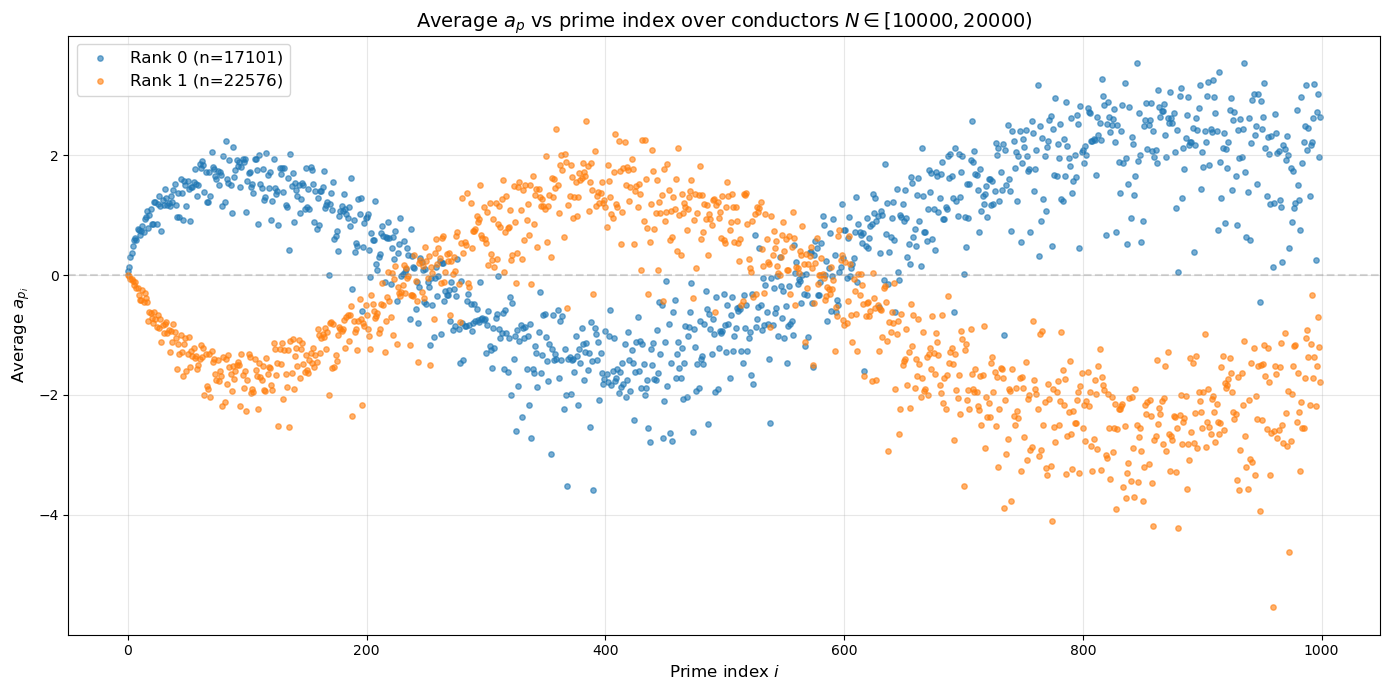

In [11]:
import matplotlib.pyplot as plt

n_primes = 1000
output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# Plot: Rank 0 vs Rank 1
plt.figure(figsize=(14, 7))
plt.scatter(range(n_primes), avg_aps_rk0, label=f"Rank 0 (n={len(Ncurves_rk0)})", alpha=0.6, s=15)
plt.scatter(range(n_primes), avg_aps_rk1, label=f"Rank 1 (n={len(Ncurves_rk1)})", alpha=0.6, s=15)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"Average $a_{p_i}$", fontsize=12)
plt.title(fr"Average $a_p$ vs prime index over conductors $N \in [{Nmin}, {Nmax})$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot1_file = os.path.join(output_dir, f"ap_averages_rank0_vs_rank1_N{Nmin}_to_{Nmax}.png")
plt.savefig(plot1_file, dpi=150)
print(f"  Saved plot: {plot1_file}")
plt.show()

In [3]:
r = 2 # rescale factor on the conductor range: [10 000, 20 000] -> [20 000, 40 000]
Nmin_r = r*Nmin
Nmax_r = r*Nmax

# ── Filter both ranks by conductor ──
Nisos_rk0_r, Ncurves_rk0_r = [], {}
for iso in tqdm(list(rk0_curves.keys()), 'Conductor range (rank 0)'):
    N = rk0_curves[iso]['conductor']
    if Nmin_r <= N <= Nmax_r:
        Nisos_rk0_r.append(iso)
        Ncurves_rk0_r[iso] = rk0_curves[iso]

Nisos_rk1_r, Ncurves_rk1_r = [], {}
for iso in tqdm(list(rk1_curves.keys()), 'Conductor range (rank 1)'):
    N = rk1_curves[iso]['conductor']
    if Nmin_r <= N <= Nmax_r:
        Nisos_rk1_r.append(iso)
        Ncurves_rk1_r[iso] = rk1_curves[iso]

Conductor range (rank 1): 100%|████████████████████████████████████████████| 222439/222439 [00:00<00:00, 1126129.37it/s]


In [7]:
from tqdm import tqdm
import numpy as np

n_primes = 1000

# Primes we'll actually sample: indices r, 2r, ..., n_primes*r  (1-indexed)
all_primes = primes_first_n(int(r * n_primes))
sample_idx = [int(r * (i + 1)) - 1 for i in range(n_primes)]   # 0-indexed
sample_primes = [all_primes[i] for i in sample_idx]

n_curves_rk0 = len(Nisos_rk0_r)
ap_matrix_rk0 = np.empty((n_curves_rk0, n_primes), dtype=np.int64)

for n in tqdm(range(n_curves_rk0), desc='rk0 aplists'):
    for i in tqdm(range(n_primes), 'Prime parsing'):
        ap_matrix_rk0[n][i] = EllipticCurve(Nisos_rk0_r[n]).ap(sample_primes[i])

avg_aps_rk0_r = ap_matrix_rk0.mean(axis=0)   # shape: (n_primes,)

n_curves_rk1 = len(Nisos_rk1_r)
ap_matrix_rk1 = np.empty((n_curves_rk1, n_primes), dtype=np.int64)

for n in tqdm(range(n_curves_rk1), desc='rk1 aplists'):
    for i in tqdm(range(n_primes), 'Prime parsing'):
        ap_matrix_rk1[n][i] = EllipticCurve(Nisos_rk1_r[n]).ap(sample_primes[i])

avg_aps_rk1_r = ap_matrix_rk1.mean(axis=0)   # shape: (n_primes,)

Prime parsing:   3%|██▏                                                               | 34/1000 [00:03<01:42,  9.39it/s]/projects/ruehlehet/luigi/sage/local/var/lib/sage/venv-python3.12/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:718: RuntimeWarning: cypari2 leaked 22627476077304 bytes on the PARI stack
  self.io_loop.add_callback(lambda: self._handle_events(self.socket, 0))

Prime parsing:   7%|████▍                                                             | 67/1000 [00:07<01:37,  9.56it/s]

ERROR: inconsistent avma when removing Gen from PARI stack
Expected: 0x14945eac7af8
Actual:   0x14945eac8000



Prime parsing:  10%|██████▌                                                          | 101/1000 [00:11<01:28, 10.10it/s]

ERROR: inconsistent avma when removing Gen from PARI stack
Expected: 0x14945eac7af8
Actual:   0x14945eac8000



Prime parsing:  17%|██████████▊                                                      | 166/1000 [00:27<05:32,  2.51it/s]

...

ERROR: inconsistent avma when removing Gen from PARI stack
Expected: 0x14945eac7af8
Actual:   0x14945eac8000



Prime parsing:  89%|██████████████████████████████████████████████████████████       | 893/1000 [01:50<00:12,  8.26it/s]

ERROR: inconsistent avma when removing Gen from PARI stack
Expected: 0x14945eac7af8
Actual:   0x14945eac8000



rk0 aplists:   0%|                                                              | 1/34309 [02:15<1293:00:40, 135.68s/it]


KeyboardInterrupt: 

In [14]:
from tqdm import tqdm

# Compute average aps from precomputed aps
aps_rk0_r = [list(Ncurves_rk0_r.values())[n]['ap_list'] for n in range(len(Ncurves_rk0_r))]
aps_rk1_r = [list(Ncurves_rk1_r.values())[n]['ap_list'] for n in range(len(Ncurves_rk1_r))]

avg_aps_rk0_r = np.mean(aps_rk0_r, axis=0)
avg_aps_rk1_r = np.mean(aps_rk1_r, axis=0)

  Saved plot: Conductor_Rescaling/ap_averages_rank0_vs_rank1_N20000_to_40000.png


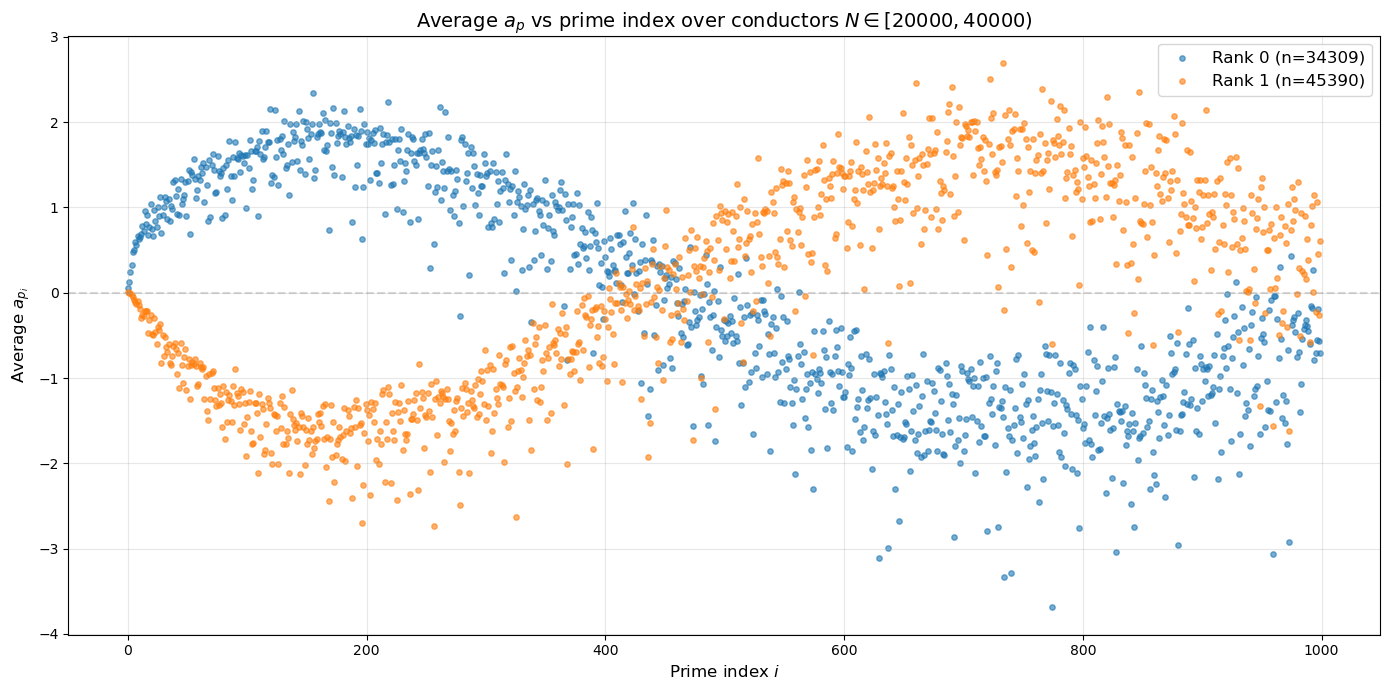

In [7]:
import matplotlib.pyplot as plt

n_primes = 1000
output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# Plot: Rank 0 vs Rank 1
plt.figure(figsize=(14, 7))
plt.scatter(range(n_primes), avg_aps_rk0_r, label=f"Rank 0 (n={len(Ncurves_rk0_r)})", alpha=0.6, s=15)
plt.scatter(range(n_primes), avg_aps_rk1_r, label=f"Rank 1 (n={len(Ncurves_rk1_r)})", alpha=0.6, s=15)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"Average $a_{p_i}$", fontsize=12)
plt.title(fr"Average $a_p$ vs prime index over conductors $N \in [{Nmin_r}, {Nmax_r})$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot1_file = os.path.join(output_dir, f"ap_averages_rank0_vs_rank1_N{Nmin_r}_to_{Nmax_r}.png")
plt.savefig(plot1_file, dpi=150)
print(f"  Saved plot: {plot1_file}")
plt.show()

In [15]:
nisos_rk0_r = len(Nisos_rk0_r)
nisos_rk1_r = len(Nisos_rk1_r)
nisos_rk0 = len(Nisos_rk0)
nisos_rk1 = len(Nisos_rk1)
nisos_rk0_tot = nisos_rk0 + nisos_rk0_r
nisos_rk1_tot = nisos_rk1 + nisos_rk1_r

rescaled_aps_rk0 = []
rescaled_aps_rk1 = []
for i in range(n_primes/r):
    rescaled_aps_rk0.append(avg_aps_rk0_r[r*i])
    rescaled_aps_rk1.append(avg_aps_rk1_r[r*i])
    
rescaled_aps_rk0 = np.array(rescaled_aps_rk0)
rescaled_aps_rk1 = np.array(rescaled_aps_rk1)

combined_aps_rk0 = (avg_aps_rk0[:n_primes/r] * nisos_rk0 + rescaled_aps_rk0 * nisos_rk0_r)/nisos_rk0_tot
combined_aps_rk1 = (avg_aps_rk1[:n_primes/r] * nisos_rk1 + rescaled_aps_rk1 * nisos_rk1_r)/nisos_rk1_tot

  Saved plot: Conductor_Rescaling/rescaled_ap_averages_rank0_vs_rank1_N10000_20000_+rescaling_r2.png


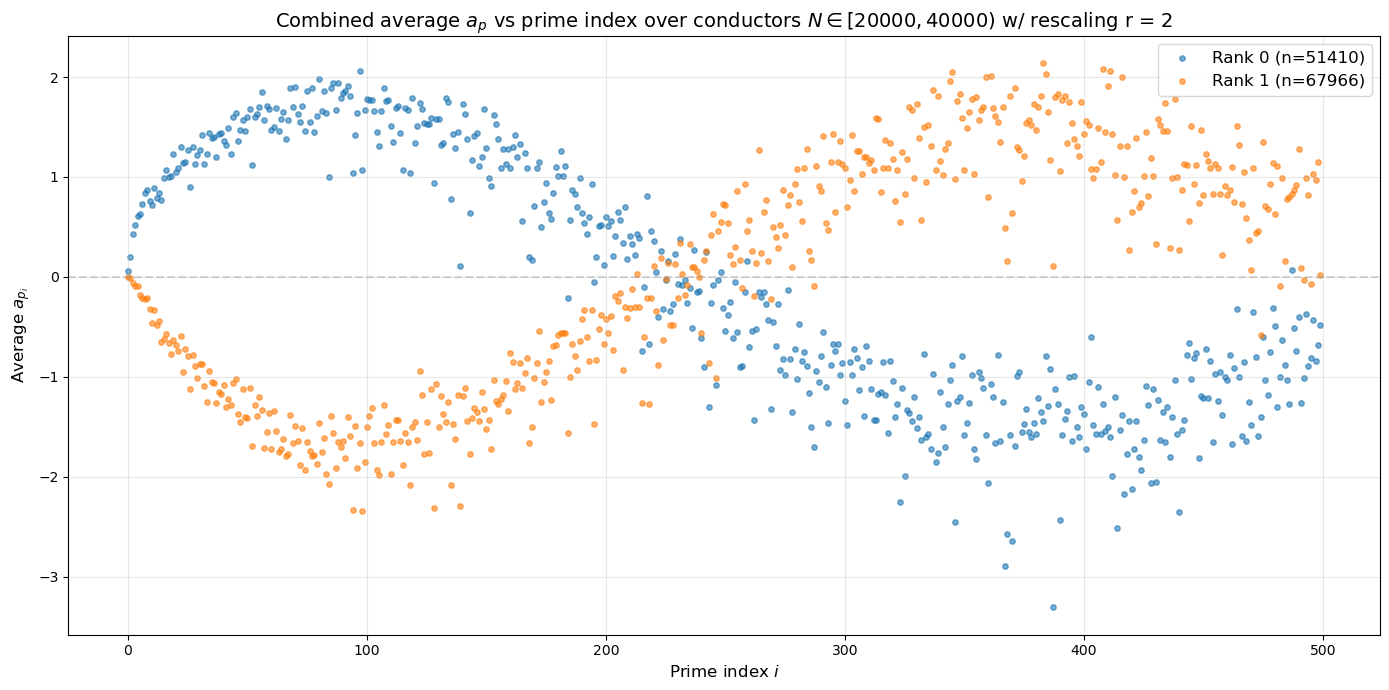

In [9]:
import matplotlib.pyplot as plt

r_primes = n_primes//r
output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# Plot: Rank 0 vs Rank 1
plt.figure(figsize=(14, 7))
plt.scatter(range(r_primes), combined_aps_rk0, label=f"Rank 0 (n={nisos_rk0_tot})", alpha=0.6, s=15)
plt.scatter(range(r_primes), combined_aps_rk1, label=f"Rank 1 (n={nisos_rk1_tot})", alpha=0.6, s=15)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"Average $a_{p_i}$", fontsize=12)
plt.title(fr"Combined average $a_p$ vs prime index over conductors $N \in [{Nmin_r}, {Nmax_r})$ w/ rescaling r = {r}", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot1_file = os.path.join(output_dir, f"rescaled_ap_averages_rank0_vs_rank1_N{Nmin}_{Nmax}_+rescaling_r{r}.png")
plt.savefig(plot1_file, dpi=150)
print(f"  Saved plot: {plot1_file}")
plt.show()

Saved: Conductor_Rescaling/rescaling_comparison_N10000_20000_r2.png


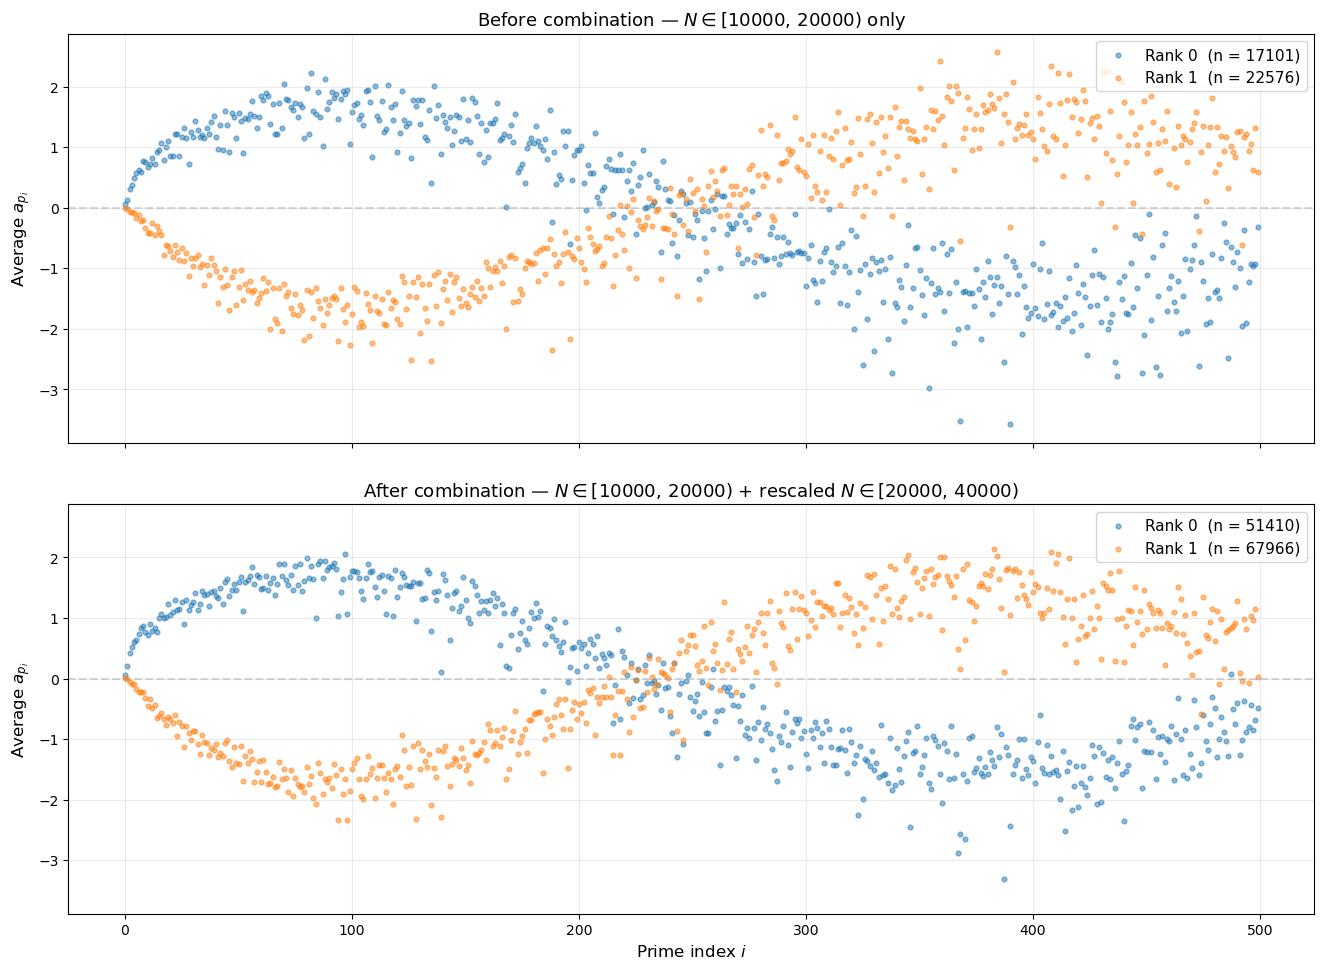

In [16]:
"""
Comparison plot: murmuration signal before vs after conductor-rescaling combination.

Shows rank 0 and rank 1 average a_p curves from the base window [Nmin, Nmax]
alongside the combined (base + rescaled) curves, so you can see the noise reduction.

Paste this into a cell in ConductorRescaling.ipynb after the combination cell.
All variables (avg_aps_rk0, avg_aps_rk1, combined_aps_rk0, combined_aps_rk1,
Ncurves_rk0, Ncurves_rk1, nisos_rk0_tot, nisos_rk1_tot, etc.) are assumed live.
"""

import matplotlib.pyplot as plt
import numpy as np
import os

# ── Parameters (must match notebook) ──
r = 2
n_primes = 1000
r_primes = n_primes // r  # 500 prime indices after downsampling
Nmin = 10000
Nmax = 20000
Nmin_r = r * Nmin
Nmax_r = r * Nmax

output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# ── Figure: 2 rows, shared x-axis ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Top panel: base window only (first r_primes indices for fair comparison) ---
ax1.scatter(range(r_primes), avg_aps_rk0[:r_primes],
            label=f"Rank 0  (n = {len(Ncurves_rk0)})",
            alpha=0.5, s=12, color='#1f77b4')
ax1.scatter(range(r_primes), avg_aps_rk1[:r_primes],
            label=f"Rank 1  (n = {len(Ncurves_rk1)})",
            alpha=0.5, s=12, color='#ff7f0e')
ax1.axhline(0, color='gray', ls='--', alpha=0.3)
ax1.set_ylabel(r"Average $a_{p_i}$", fontsize=12)
ax1.set_title(fr"Before combination — $N \in [{Nmin},\, {Nmax})$ only", fontsize=13)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.25)

# --- Bottom panel: combined (base + rescaled) ---
ax2.scatter(range(r_primes), combined_aps_rk0,
            label=f"Rank 0  (n = {nisos_rk0_tot})",
            alpha=0.5, s=12, color='#1f77b4')
ax2.scatter(range(r_primes), combined_aps_rk1,
            label=f"Rank 1  (n = {nisos_rk1_tot})",
            alpha=0.5, s=12, color='#ff7f0e')
ax2.axhline(0, color='gray', ls='--', alpha=0.3)
ax2.set_xlabel(r"Prime index $i$", fontsize=12)
ax2.set_ylabel(r"Average $a_{p_i}$", fontsize=12)
ax2.set_title(
    fr"After combination — $N \in [{Nmin},\, {Nmax})$ + rescaled $N \in [{Nmin_r},\, {Nmax_r})$",
    fontsize=13)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.25)

# ── Match y-limits so the visual comparison is honest ──
ylo = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
yhi = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(ylo, yhi)
ax2.set_ylim(ylo, yhi)

fig.subplots_adjust(hspace=0.15, left=0.08, right=0.97, top=0.95, bottom=0.07)
fname = os.path.join(output_dir,
    f"rescaling_comparison_N{Nmin}_{Nmax}_r{r}.png")
plt.savefig(fname, dpi=150)
print(f"Saved: {fname}")
plt.show()

In [3]:
HV_scan_data = load('phi_scan_results/(-2000,2000)_phi_scan_data.sobj')

In [17]:
HV_scan_data.keys()

dict_keys(['phi_reps', 'conductors', 'isogeny_classes', 'total_phis_generated', 'total_found', 'nmin', 'nmax'])

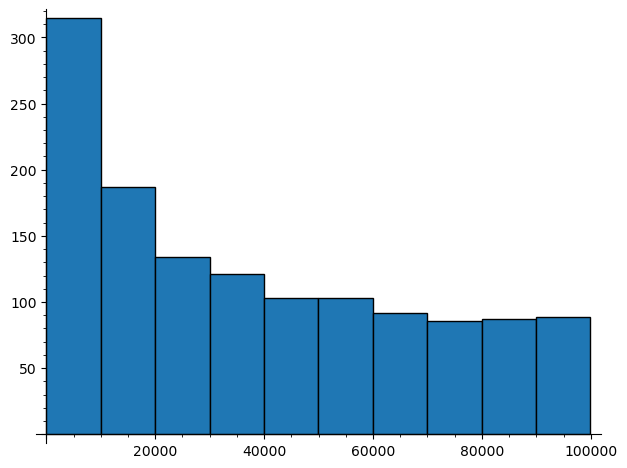

In [24]:
histogram(HV_scan_data['conductors'], density=False)

In [39]:
def hv_curve(phi):
    a = -(9*phi**4 - 12*phi**3 + 30*phi**2 - 12*phi + 1)/3
    b = -2*(27*phi**6 - 54*phi**5 - 135*phi**4 + 180*phi**3 - 99*phi**2 + 18*phi - 1)/27
    
    return EllipticCurve([a,b])

def get_isogeny_class(label):
    """Extract isogeny class from curve label: '11a1' -> '11a'"""
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

In [9]:
Nmin = 10000
Nmax = 20000

i_HV = [i for i, x in enumerate(HV_scan_data['conductors']) if Nmin <= x <= Nmax]
phis = [HV_scan_data['phi_reps'][i] for i in i_HV]

print(f'Number of curves with N in [{Nmin}, {Nmax}]: {len(i_HV)}')

i_rk0 = []
i_rk1 = []
for i in i_HV:
    iso = HV_scan_data['isogeny_classes'][i]
    rk = curve_db[iso]['rank']
    if rk == 0:
        i_rk0.append(i)
    elif rk == 1:
        i_rk1.append(i)

print(f'Rank 0 curves: {len(i_rk0)}')
print(f'Rank 1 curves: {len(i_rk1)}')

isos_rk0 = [HV_scan_data['isogeny_classes'][i] for i in i_rk0]
isos_rk1 = [HV_scan_data['isogeny_classes'][i] for i in i_rk1]

# ── Filter both ranks by conductor ──
Nisos_rk0, Ncurves_rk0 = [], {}
for iso in tqdm(isos_rk0, 'Conductor range (rank 0)'):
    Nisos_rk0.append(iso)
    Ncurves_rk0[iso] = rk0_curves[iso]

Nisos_rk1, Ncurves_rk1 = [], {}
for iso in tqdm(isos_rk1, 'Conductor range (rank 1)'):
    Nisos_rk1.append(iso)
    Ncurves_rk1[iso] = rk1_curves[iso]

Number of curves with N in [10000, 20000]: 187
Rank 0 curves: 98
Rank 1 curves: 83


Conductor range (rank 1): 100%|█████████████████████████████████████████████████████| 83/83 [00:00<00:00, 686641.48it/s]


In [100]:
import numpy as np

# Compute average aps from precomputed aps
aps_rk0 = [list(Ncurves_rk0.values())[n]['ap_list'] for n in range(len(Ncurves_rk0))]
aps_rk1 = [list(Ncurves_rk1.values())[n]['ap_list'] for n in range(len(Ncurves_rk1))]

avg_aps_rk0 = np.mean(aps_rk0, axis=0)
avg_aps_rk1 = np.mean(aps_rk1, axis=0)

  Saved plot: Conductor_Rescaling/HV_ap_averages_rank0_vs_rank1_N5000_to_10000.png


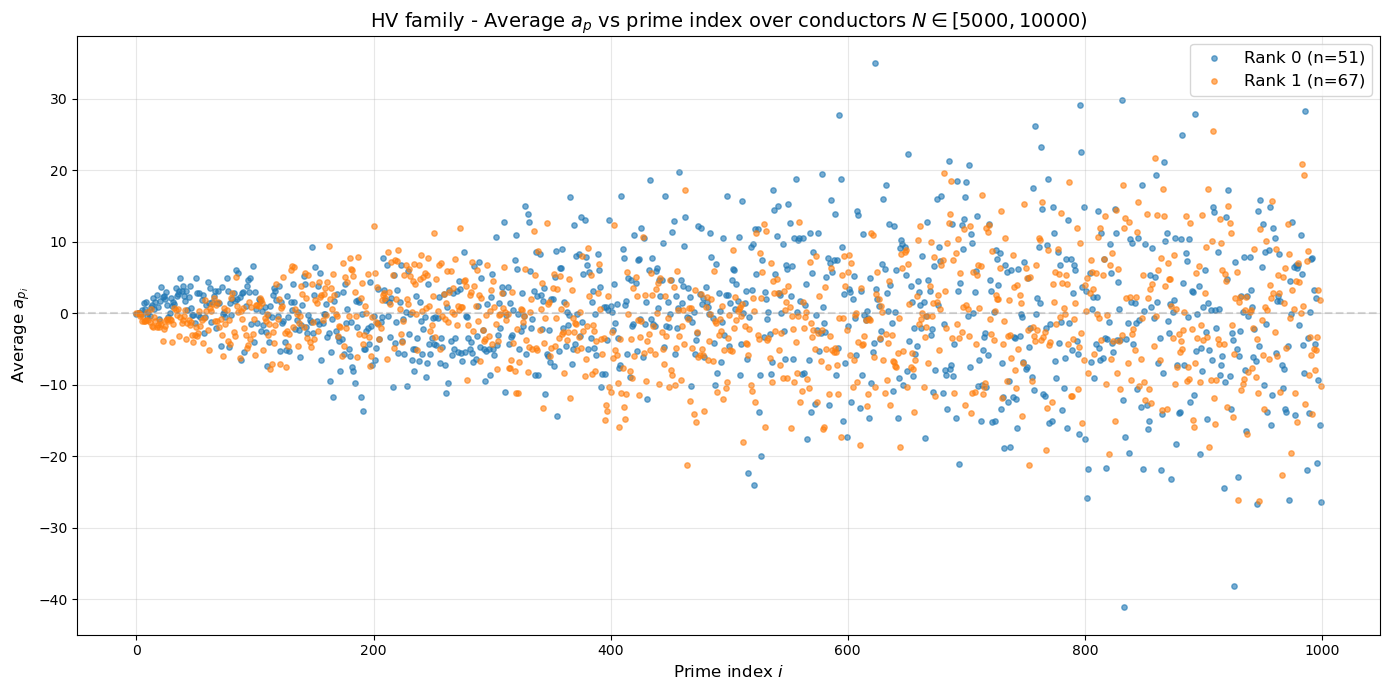

In [69]:
import matplotlib.pyplot as plt

n_primes = 1000
output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# Plot: Rank 0 vs Rank 1
plt.figure(figsize=(14, 7))
plt.scatter(range(n_primes), avg_aps_rk0, label=f"Rank 0 (n={len(Ncurves_rk0)})", alpha=0.6, s=15)
plt.scatter(range(n_primes), avg_aps_rk1, label=f"Rank 1 (n={len(Ncurves_rk1)})", alpha=0.6, s=15)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"Average $a_{p_i}$", fontsize=12)
plt.title(fr"HV family - Average $a_p$ vs prime index over conductors $N \in [{Nmin}, {Nmax})$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot1_file = os.path.join(output_dir, f"HV_ap_averages_rank0_vs_rank1_N{Nmin}_to_{Nmax}.png")
plt.savefig(plot1_file, dpi=150)
print(f"  Saved plot: {plot1_file}")
plt.show()

In [104]:
r = 2 # rescale factor on the conductor range: [10 000, 20 000] -> [20 000, 40 000]
Nmin_r = r*Nmin
Nmax_r = r*Nmax

i_HV_r = [i for i, x in enumerate(HV_scan_data['conductors']) if Nmin_r <= x <= Nmax_r if i not in i_HV]

print(f'Number of curves with N in [{Nmin_r}, {Nmax_r}]: {len(i_HV_r)}')

i_rk0_r = []
i_rk1_r = []
for i in i_HV_r:
    iso = HV_scan_data['isogeny_classes'][i]
    rk = curve_db[iso]['rank']
    if rk == 0:
        i_rk0_r.append(i)
    elif rk == 1:
        i_rk1_r.append(i)

print(f'Rank 0 curves: {len(i_rk0_r)}')
print(f'Rank 1 curves: {len(i_rk1_r)}')

isos_rk0_r = [HV_scan_data['isogeny_classes'][i] for i in i_rk0_r]
isos_rk1_r = [HV_scan_data['isogeny_classes'][i] for i in i_rk1_r]

# ── Filter both ranks by conductor ──
Nisos_rk0_r, Ncurves_rk0_r = [], {}
for iso in tqdm(isos_rk0_r, 'Conductor range (rank 0)'):
    Nisos_rk0_r.append(iso)
    Ncurves_rk0_r[iso] = rk0_curves[iso]

Nisos_rk1_r, Ncurves_rk1_r = [], {}
for iso in tqdm(isos_rk1_r, 'Conductor range (rank 1)'):
    Nisos_rk1_r.append(iso)
    Ncurves_rk1_r[iso] = rk1_curves[iso]

Number of curves with N in [10000, 20000]: 187
Rank 0 curves: 98
Rank 1 curves: 83


Conductor range (rank 1): 100%|█████████████████████████████████████████████████████| 83/83 [00:00<00:00, 720760.31it/s]


In [105]:
from tqdm import tqdm
import numpy as np

n_primes = 1000

# Primes we'll actually sample: indices r, 2r, ..., n_primes*r  (1-indexed)
all_primes = primes_first_n(int(r * n_primes))
prime_bound = all_primes[-1]
sample_idx = [int(r * (i + 1)) - 1 for i in range(n_primes)]   # 0-indexed

n_curves_rk0 = len(Nisos_rk0_r)
ap_matrix_rk0 = np.empty((n_curves_rk0, n_primes), dtype=np.int64)

for n in tqdm(range(n_curves_rk0), desc='rk0 aplists'):
    full = EllipticCurve(Nisos_rk0_r[n]).aplist(prime_bound)
    ap_matrix_rk0[n] = [full[j] for j in sample_idx]

avg_aps_rk0_r = ap_matrix_rk0.mean(axis=0)   # shape: (n_primes,)

n_curves_rk1 = len(Nisos_rk1_r)
ap_matrix_rk1 = np.empty((n_curves_rk1, n_primes), dtype=np.int64)

for n in tqdm(range(n_curves_rk1), desc='rk1 aplists'):
    full = EllipticCurve(Nisos_rk1_r[n]).aplist(prime_bound)
    ap_matrix_rk1[n] = [full[j] for j in sample_idx]

avg_aps_rk1_r = ap_matrix_rk1.mean(axis=0)   # shape: (n_primes,)

rk1 aplists: 100%|██████████████████████████████████████████████████████████████████████| 83/83 [00:10<00:00,  7.55it/s]


  Saved plot: Conductor_Rescaling/HV_ap_averages_rank0_vs_rank1_N10000_to_20000.png


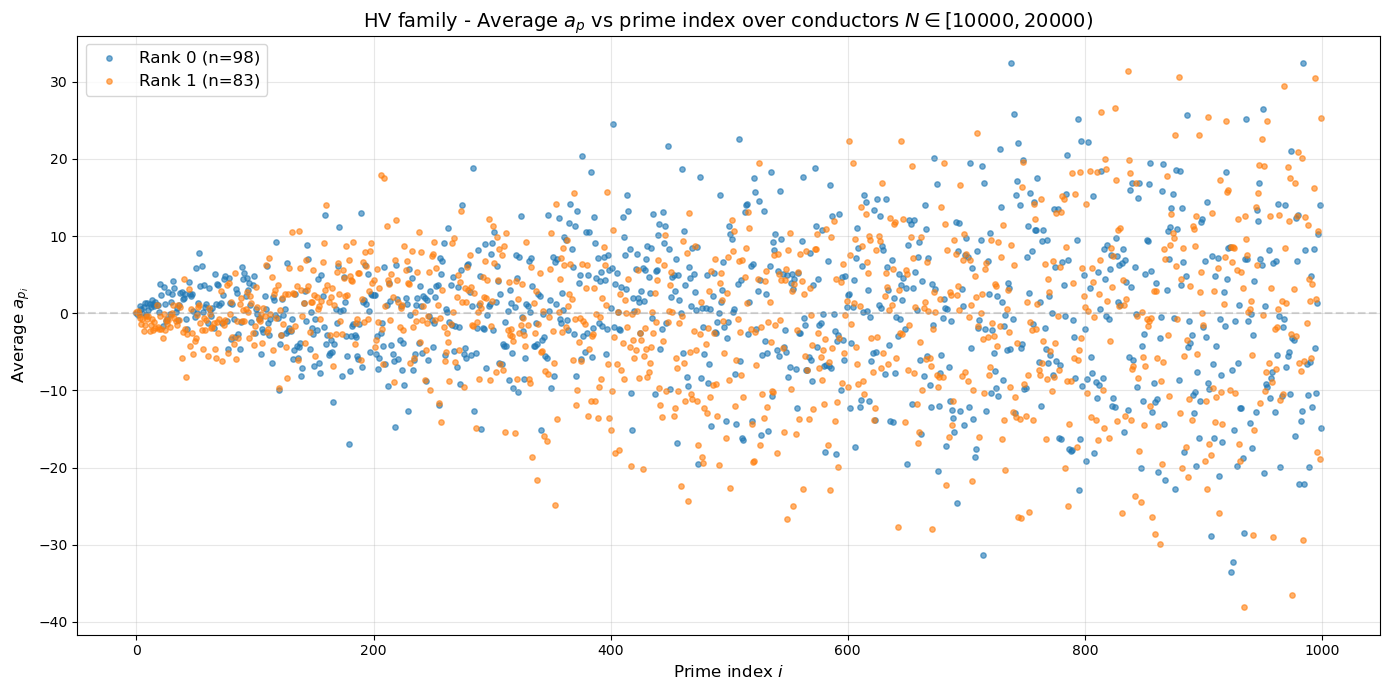

In [72]:
import matplotlib.pyplot as plt

n_primes = 1000
output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# Plot: Rank 0 vs Rank 1
plt.figure(figsize=(14, 7))
plt.scatter(range(n_primes), avg_aps_rk0_r, label=f"Rank 0 (n={len(Ncurves_rk0_r)})", alpha=0.6, s=15)
plt.scatter(range(n_primes), avg_aps_rk1_r, label=f"Rank 1 (n={len(Ncurves_rk1_r)})", alpha=0.6, s=15)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"Average $a_{p_i}$", fontsize=12)
plt.title(fr"HV family - Average $a_p$ vs prime index over conductors $N \in [{Nmin_r}, {Nmax_r})$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot1_file = os.path.join(output_dir, f"HV_ap_averages_rank0_vs_rank1_N{Nmin_r}_to_{Nmax_r}.png")
plt.savefig(plot1_file, dpi=150)
print(f"  Saved plot: {plot1_file}")
plt.show()

In [106]:
nisos_rk0_r = len(Nisos_rk0_r)
nisos_rk1_r = len(Nisos_rk1_r)
nisos_rk0 = len(Nisos_rk0)
nisos_rk1 = len(Nisos_rk1)
nisos_rk0_tot = nisos_rk0 + nisos_rk0_r
nisos_rk1_tot = nisos_rk1 + nisos_rk1_r

combined_aps_rk0 = (avg_aps_rk0 * nisos_rk0 + avg_aps_rk0_r * nisos_rk0_r)/nisos_rk0_tot
combined_aps_rk1 = (avg_aps_rk1 * nisos_rk1 + avg_aps_rk1_r * nisos_rk1_r)/nisos_rk1_tot

Saved: Conductor_Rescaling/HV_rescaling_comparison_N5000_10000_r2.png


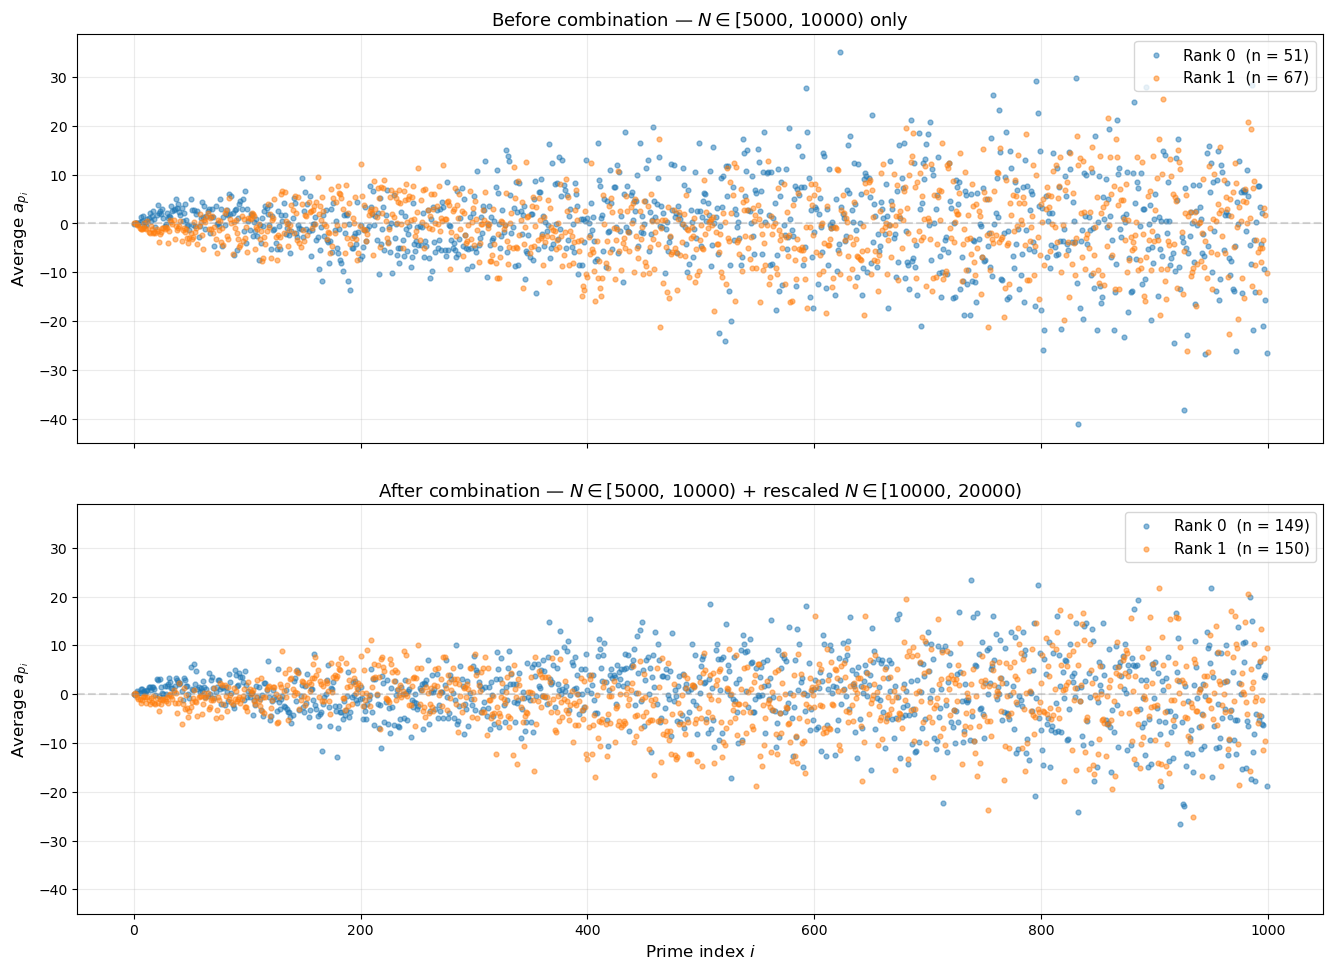

In [74]:
"""
Comparison plot: murmuration signal before vs after conductor-rescaling combination.

Shows rank 0 and rank 1 average a_p curves from the base window [Nmin, Nmax]
alongside the combined (base + rescaled) curves, so you can see the noise reduction.

Paste this into a cell in ConductorRescaling.ipynb after the combination cell.
All variables (avg_aps_rk0, avg_aps_rk1, combined_aps_rk0, combined_aps_rk1,
Ncurves_rk0, Ncurves_rk1, nisos_rk0_tot, nisos_rk1_tot, etc.) are assumed live.
"""

import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# ── Figure: 2 rows, shared x-axis ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Top panel: base window only (first r_primes indices for fair comparison) ---
ax1.scatter(range(n_primes), avg_aps_rk0,
            label=f"Rank 0  (n = {len(Ncurves_rk0)})",
            alpha=0.5, s=12, color='#1f77b4')
ax1.scatter(range(n_primes), avg_aps_rk1,
            label=f"Rank 1  (n = {len(Ncurves_rk1)})",
            alpha=0.5, s=12, color='#ff7f0e')
ax1.axhline(0, color='gray', ls='--', alpha=0.3)
ax1.set_ylabel(r"Average $a_{p_i}$", fontsize=12)
ax1.set_title(fr"Before combination — $N \in [{Nmin},\, {Nmax})$ only", fontsize=13)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.25)

# --- Bottom panel: combined (base + rescaled) ---
ax2.scatter(range(n_primes), combined_aps_rk0,
            label=f"Rank 0  (n = {nisos_rk0_tot})",
            alpha=0.5, s=12, color='#1f77b4')
ax2.scatter(range(n_primes), combined_aps_rk1,
            label=f"Rank 1  (n = {nisos_rk1_tot})",
            alpha=0.5, s=12, color='#ff7f0e')
ax2.axhline(0, color='gray', ls='--', alpha=0.3)
ax2.set_xlabel(r"Prime index $i$", fontsize=12)
ax2.set_ylabel(r"Average $a_{p_i}$", fontsize=12)
ax2.set_title(
    fr"After combination — $N \in [{Nmin},\, {Nmax})$ + rescaled $N \in [{Nmin_r},\, {Nmax_r})$",
    fontsize=13)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.25)

# ── Match y-limits so the visual comparison is honest ──
ylo = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
yhi = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(ylo, yhi)
ax2.set_ylim(ylo, yhi)

fig.subplots_adjust(hspace=0.15, left=0.08, right=0.97, top=0.95, bottom=0.07)
fname = os.path.join(output_dir,
    f"HV_rescaling_comparison_N{Nmin}_{Nmax}_r{r}.png")
plt.savefig(fname, dpi=150)
print(f"Saved: {fname}")
plt.show()

In [131]:
r = 10 # rescale factor on the conductor range: [10 000, 20 000] -> [20 000, 40 000]
Nmin_r = r*Nmin
Nmax_r = r*Nmax
i_HV_old = i_HV_r

i_HV_r = [i for i, x in enumerate(HV_scan_data['conductors']) if Nmin_r <= x <= Nmax_r if i not in i_HV_old]

print(f'Number of curves with N in [{Nmin_r}, {Nmax_r}] and not previously sampled: {len(i_HV_r)}')

i_rk0_r = []
i_rk1_r = []
for i in i_HV_r:
    iso = HV_scan_data['isogeny_classes'][i]
    rk = curve_db[iso]['rank']
    if rk == 0:
        i_rk0_r.append(i)
    elif rk == 1:
        i_rk1_r.append(i)

print(f'Rank 0 curves: {len(i_rk0_r)}')
print(f'Rank 1 curves: {len(i_rk1_r)}')

isos_rk0_r = [HV_scan_data['isogeny_classes'][i] for i in i_rk0_r]
isos_rk1_r = [HV_scan_data['isogeny_classes'][i] for i in i_rk1_r]

# ── Filter both ranks by conductor ──
Nisos_rk0_r, Ncurves_rk0_r = [], {}
for iso in tqdm(isos_rk0_r, 'Conductor range (rank 0)'):
    Nisos_rk0_r.append(iso)
    Ncurves_rk0_r[iso] = rk0_curves[iso]

Nisos_rk1_r, Ncurves_rk1_r = [], {}
for iso in tqdm(isos_rk1_r, 'Conductor range (rank 1)'):
    Nisos_rk1_r.append(iso)
    Ncurves_rk1_r[iso] = rk1_curves[iso]

Number of curves with N in [50000, 100000] and not previously sampled: 278
Rank 0 curves: 133
Rank 1 curves: 140


Conductor range (rank 1): 100%|███████████████████████████████████████████████████| 140/140 [00:00<00:00, 696562.94it/s]


In [132]:
from tqdm import tqdm
import numpy as np

n_primes = 1000

# Primes we'll actually sample: indices r, 2r, ..., n_primes*r  (1-indexed)
all_primes = primes_first_n(int(r * n_primes))
prime_bound = all_primes[-1]
sample_idx = [int(r * (i + 1)) - 1 for i in range(n_primes)]   # 0-indexed

n_curves_rk0 = len(Nisos_rk0_r)
ap_matrix_rk0 = np.empty((n_curves_rk0, n_primes), dtype=np.int64)

for n in tqdm(range(n_curves_rk0), desc='rk0 aplists'):
    full = EllipticCurve(Nisos_rk0_r[n]).aplist(prime_bound)
    ap_matrix_rk0[n] = [full[j] for j in sample_idx]

avg_aps_rk0_r = ap_matrix_rk0.mean(axis=0)   # shape: (n_primes,)

n_curves_rk1 = len(Nisos_rk1_r)
ap_matrix_rk1 = np.empty((n_curves_rk1, n_primes), dtype=np.int64)

for n in tqdm(range(n_curves_rk1), desc='rk1 aplists'):
    full = EllipticCurve(Nisos_rk1_r[n]).aplist(prime_bound)
    ap_matrix_rk1[n] = [full[j] for j in sample_idx]

avg_aps_rk1_r = ap_matrix_rk1.mean(axis=0)   # shape: (n_primes,)

rk1 aplists: 100%|████████████████████████████████████████████████████████████████████| 140/140 [00:49<00:00,  2.82it/s]


In [133]:
nisos_rk0_r = len(Nisos_rk0_r)
nisos_rk1_r = len(Nisos_rk1_r)

combined_aps_rk0 = (combined_aps_rk0 * nisos_rk0_tot + avg_aps_rk0_r * nisos_rk0_r)/(nisos_rk0_tot + nisos_rk0_r)
combined_aps_rk1 = (combined_aps_rk1 * nisos_rk1_tot + avg_aps_rk1_r * nisos_rk1_r)/(nisos_rk1_tot + nisos_rk1_r)

✓ curve_db loaded with 437226 isogeny classes
✓ HV_scan_data loaded
Building rank-restricted lookup dicts...


Splitting by rank: 100%|████████████████████████████████████████████████████| 437226/437226 [00:00<00:00, 939942.46it/s]


r =   1:  [5000, 10000]  rk0=51  rk1=67
r =   2:  [10000, 20000]  rk0=98  rk1=83


  ap (r=2): 100%|███████████████████████████████████████████████████████████████████████| 83/83 [00:06<00:00, 12.54it/s]


r =   3:  [15000, 30000]  rk0=68  rk1=60


...

r =   9:  [45000, 90000]  rk0=45  rk1=37


  ap (r=9): 100%|███████████████████████████████████████████████████████████████████████| 37/37 [00:03<00:00, 10.77it/s]


r =  10:  [50000, 100000]  rk0=40  rk1=46


  ap (r=10): 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:04<00:00, 11.07it/s]



Done.  Total curves folded in:  rk0 = 531,  rk1 = 560
Saved: Conductor_Rescaling/HV_rescaling_comparison_N5000_10000_rmax10.png


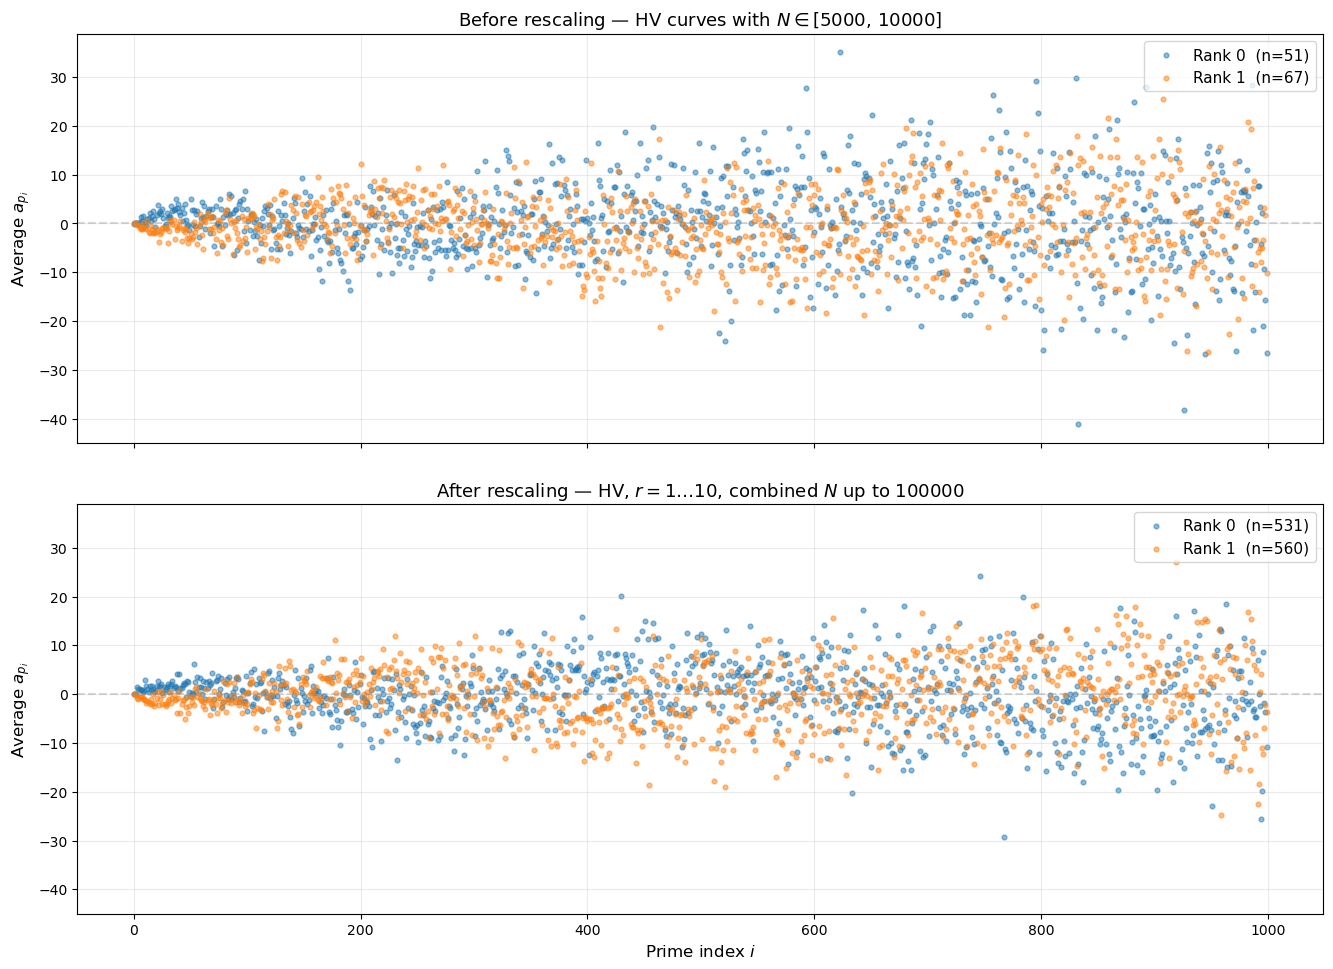

In [18]:
"""
Conductor-rescaling murmuration analysis for the Hulek–Verrill family.

For a base window [Nmin, Nmax], loops over rescaling factors r = 1, 2, …, rmax
and progressively combines the averaged a_p signal.  At each step the primes are
subsampled at stride r (i.e. we use p_{r}, p_{2r}, … , p_{r·n_primes}) so that
the ratio p / N stays comparable across windows.

Usage (SageMath):
    %runfile conductor_rescaling_loop.sage
    (requires curve_db and HV_scan_data already in the session)
"""

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

# ═══════════════════════════════════════════════════════════════════════════════
# Parameters
# ═══════════════════════════════════════════════════════════════════════════════
Nmin      = 5000
Nmax      = 10000
n_primes  = 1000
N_db_max  = 100000          # conductor ceiling of curve_db
rmax      = N_db_max // Nmax  # largest r with r·Nmax ≤ N_db_max

output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# 0. Load databases (assumed already in session; adjust paths if not)
# ═══════════════════════════════════════════════════════════════════════════════
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100000)/curve_database_N1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

try:
    HV_scan_data
    print(f"✓ HV_scan_data loaded")
except NameError:
    print("Loading HV scan data...")
    HV_scan_data = load('phi_scan_results/(-2000,2000)_phi_scan_data.sobj')
    print(f"✓ Loaded HV_scan_data")

# Pre-split curve_db by rank for fast lookup
print("Building rank-restricted lookup dicts...")
rk0_curves = {}
rk1_curves = {}
for iso, data in tqdm(curve_db.items(), desc='Splitting by rank'):
    rk = data['rank']
    if rk == 0:
        rk0_curves[iso] = data
    elif rk == 1:
        rk1_curves[iso] = data

# ═══════════════════════════════════════════════════════════════════════════════
# Helper: compute stride-r averaged a_p for a list of isogeny class labels
# ═══════════════════════════════════════════════════════════════════════════════
def compute_avg_aps(iso_labels, r, n_primes):
    """
    For each curve in iso_labels, compute a_p at primes p_{r}, p_{2r}, …, p_{r·n_primes}
    and return the per-prime average.  Returns None if iso_labels is empty.
    """
    n = len(iso_labels)
    if n == 0:
        return None

    if r == 1:
        # Use precomputed ap_list from curve_db (first n_primes entries)
        mat = np.array([curve_db[iso]['ap_list'][:n_primes] for iso in iso_labels],
                       dtype=np.float64)
    else:
        all_primes    = primes_first_n(int(r * n_primes))
        sample_primes = [all_primes[int(r * (i + 1)) - 1] for i in range(n_primes)]
        
        mat = np.empty((n, n_primes), dtype=np.int64)
        for k in tqdm(range(n), desc=f'  ap (r={r})'):
            E = EllipticCurve(iso_labels[k])
            mat[k] = [E.ap(p) for p in sample_primes]

    return mat.mean(axis=0)


# ═══════════════════════════════════════════════════════════════════════════════
# Main loop over rescaling factors
# ═══════════════════════════════════════════════════════════════════════════════
used_indices = set()           # HV_scan_data indices already folded in

combined_rk0 = None            # running weighted average (n_primes,)
combined_rk1 = None
ntot_rk0     = 0               # running curve counts
ntot_rk1     = 0

history = []                   # for diagnostics / plotting

for r in range(1, rmax + 1):
    Nlo = r * Nmin
    Nhi = r * Nmax

    # ── Find HV curves in this conductor window, excluding duplicates ──
    i_window = [i for i, N in enumerate(HV_scan_data['conductors'])
                if Nlo <= N <= Nhi and i not in used_indices]

    if len(i_window) == 0:
        print(f"r = {r:>3d}:  [{Nlo}, {Nhi}]  — no new curves, skipping")
        continue

    # Split by rank
    isos_rk0, isos_rk1 = [], []
    for i in i_window:
        iso = HV_scan_data['isogeny_classes'][i]
        if iso not in curve_db:
            continue                    # conductor beyond curve_db
        rk = curve_db[iso]['rank']
        if rk == 0:
            isos_rk0.append(iso)
        elif rk == 1:
            isos_rk1.append(iso)

    n0, n1 = len(isos_rk0), len(isos_rk1)
    print(f"r = {r:>3d}:  [{Nlo}, {Nhi}]  rk0={n0}  rk1={n1}")

    if n0 == 0 and n1 == 0:
        continue

    # Mark these indices as used
    used_indices.update(i_window)

    # ── Compute stride-r averaged a_p ──
    avg0 = compute_avg_aps(isos_rk0, r, n_primes)
    avg1 = compute_avg_aps(isos_rk1, r, n_primes)

    # ── Weighted combination (use old total, then update) ──
    if avg0 is not None and n0 > 0:
        if combined_rk0 is None:
            combined_rk0 = avg0
            ntot_rk0     = n0
        else:
            combined_rk0 = (combined_rk0 * ntot_rk0 + avg0 * n0) / (ntot_rk0 + n0)
            ntot_rk0    += n0

    if avg1 is not None and n1 > 0:
        if combined_rk1 is None:
            combined_rk1 = avg1
            ntot_rk1     = n1
        else:
            combined_rk1 = (combined_rk1 * ntot_rk1 + avg1 * n1) / (ntot_rk1 + n1)
            ntot_rk1    += n1

    history.append(dict(r=r, n0=n0, n1=n1, ntot0=ntot_rk0, ntot1=ntot_rk1))

fname = os.path.join(output_dir, f"HV_combined_aps_rk0_N{Nmin}_{Nmax}")
save(combined_rk0, fname)

print(f'Saved {fname}')

fname = os.path.join(output_dir, f"HV_combined_aps_rk1_N{Nmin}_{Nmax}")
save(combined_rk1, fname)

print(f'Saved {fname}')

fname = os.path.join(output_dir, f"HV_history_N{Nmin}_{Nmax}")
save(history, fname)

print(f'Saved {fname}')

print(f"\nDone.  Total curves folded in:  rk0 = {ntot_rk0},  rk1 = {ntot_rk1}")

# ═══════════════════════════════════════════════════════════════════════════════
# Plots
# ═══════════════════════════════════════════════════════════════════════════════

# --- 1. Base window only (r = 1) vs combined ---
# Recover the r = 1 averages for comparison
i_base = [i for i, N in enumerate(HV_scan_data['conductors'])
          if Nmin <= N <= Nmax]
isos_base_rk0 = [HV_scan_data['isogeny_classes'][i] for i in i_base
                  if HV_scan_data['isogeny_classes'][i] in rk0_curves]
isos_base_rk1 = [HV_scan_data['isogeny_classes'][i] for i in i_base
                  if HV_scan_data['isogeny_classes'][i] in rk1_curves]
base_avg0 = compute_avg_aps(isos_base_rk0, 1, n_primes)
base_avg1 = compute_avg_aps(isos_base_rk1, 1, n_primes)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.scatter(range(n_primes), base_avg0, label=f"Rank 0  (n={len(isos_base_rk0)})",
            alpha=0.5, s=12, color='#1f77b4')
ax1.scatter(range(n_primes), base_avg1, label=f"Rank 1  (n={len(isos_base_rk1)})",
            alpha=0.5, s=12, color='#ff7f0e')
ax1.axhline(0, color='gray', ls='--', alpha=0.3)
ax1.set_ylabel(r"Average $a_{p_i}$", fontsize=12)
ax1.set_title(fr"Before rescaling — HV curves with $N \in [{Nmin},\, {Nmax}]$", fontsize=13)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.25)

ax2.scatter(range(n_primes), combined_rk0, label=f"Rank 0  (n={ntot_rk0})",
            alpha=0.5, s=12, color='#1f77b4')
ax2.scatter(range(n_primes), combined_rk1, label=f"Rank 1  (n={ntot_rk1})",
            alpha=0.5, s=12, color='#ff7f0e')
ax2.axhline(0, color='gray', ls='--', alpha=0.3)
ax2.set_xlabel(r"Prime index $i$", fontsize=12)
ax2.set_ylabel(r"Average $a_{p_i}$", fontsize=12)
ax2.set_title(
    fr"After rescaling — HV, $r = 1 \ldots {rmax}$, combined $N$ up to ${rmax * Nmax}$",
    fontsize=13)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.25)

ylo = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
yhi = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(ylo, yhi)
ax2.set_ylim(ylo, yhi)

fig.subplots_adjust(hspace=0.15, left=0.08, right=0.97, top=0.95, bottom=0.07)
fname = os.path.join(output_dir, f"HV_rescaling_comparison_N{Nmin}_{Nmax}_rmax{rmax}.png")
plt.savefig(fname, dpi=150)
print(f"Saved: {fname}")
plt.show()

In [5]:
aps_rk0 = load('Conductor_Rescaling/HV_combined_aps_rk0_N5000_10000.sobj')
aps_rk1 = load('Conductor_Rescaling/HV_combined_aps_rk1_N5000_10000.sobj')
Nmin = 5000
Nmax = 10000

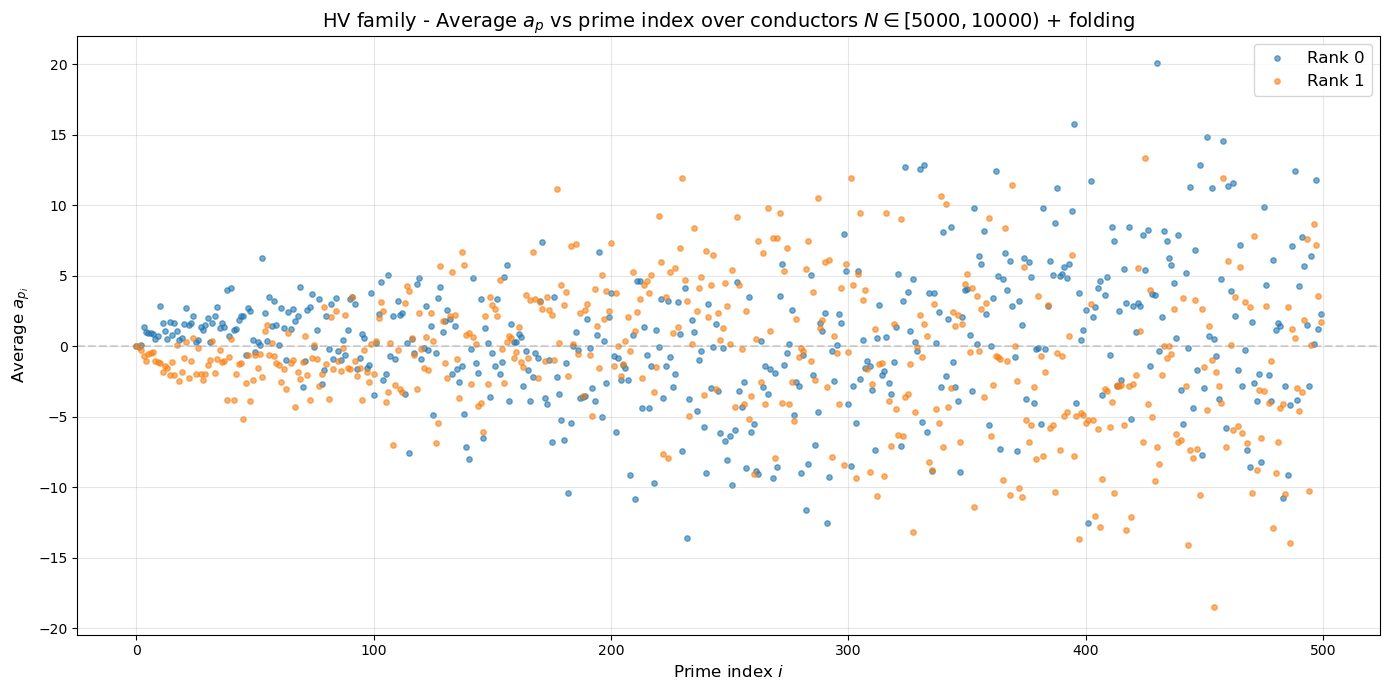

In [7]:
import matplotlib.pyplot as plt

n_primes = 500
output_dir = 'Conductor_Rescaling/'
os.makedirs(output_dir, exist_ok=True)

# Plot: Rank 0 vs Rank 1
plt.figure(figsize=(14, 7))
plt.scatter(range(n_primes), aps_rk0[:n_primes], label=f"Rank 0", alpha=0.6, s=15)
plt.scatter(range(n_primes), aps_rk1[:n_primes], label=f"Rank 1", alpha=0.6, s=15)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.xlabel(r"Prime index $i$", fontsize=12)
plt.ylabel(r"Average $a_{p_i}$", fontsize=12)
plt.title(fr"HV family - Average $a_p$ vs prime index over conductors $N \in [{Nmin}, {Nmax})$ + folding", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot1_file = os.path.join(output_dir, f"ap_averages_rank0_vs_rank1_N{Nmin}_to_{Nmax}.png")
# plt.savefig(plot1_file, dpi=150)
# print(f"  Saved plot: {plot1_file}")
plt.show()